[![Open In Colab](./colab-badge.png)](https://colab.research.google.com/github/subhacom/moose-notebooks/blob/main/Dynamical_system_with_NaP.ipynb) [![Binder](./binder_logo.png)](https://mybinder.org/v2/gh/subhacom/moose-notebooks/HEAD?labpath=Dynamical_system_with_NaP.ipynb)

# Neuronal model and dynamical system in one dimension

*This tutorial introduces a 1-dimensional dynamical system following the book "Dynamical Systems in Neuroscience" by Eugene Izhikevich.*

The Hodgkin-Huxley model of neuronal activity is biologically realistic, but it can be hard to analyze mathematically. The study of *dynamical systems* in mathematics provide insight into systems, including biological neurons, that change their state over time.

Now, what is a dynamical system? What does state mean?

We all have an implicit understanding of *system* as an English word. In the domain of physics and mathematics, we can think of a system as an abstraction where we consider a small set of objects, forces, and rules in isolation from the rest of the universe. 

For example an oscillating pendulam under the force of gravity is a system. So can be a marble rolling inside a bowl under gravity. There is a very large number of atoms in the marble, each experiencing the force of gravity, there is air surrounding it and applying viscous force, there is force of friction where it touches the bowl, making the system overwhelingly complex for us to analyze. To get to the essence of the behavior of the marble, we ignore all those details, and think of it as a point mass, and study its velocity and accelaration as it changes position with time.

All else remaining constant, the position and the velocity of the marble determines the *state* of the system, and given the state at time $t$, we can infer, based on the laws of physics, the state at a future point in time, $t + \Delta t$. We call these the state variables of the system.

Similarly, in case of a passive neuronal compartment, the state is determined by its membrane voltage $V_{m}$.

In the Hodgking-Huxley model, the state variables are the membrane voltage $V_{m}$, the $Na^{+}$ channel activation variable $m$ and inactivation variable $h$, and the activation variable $n$ of the $K^{+}$ channel. Once we have the equations describing them, we can calculate their future values based on their current values and any external input like current injection or synaptic input.

From the equations for the state variables we can get high-level insight into how the system may behave under various conditions. Here we start with a simplified scenario where where a neuron's state is described by two variables: $V_{m}$ and $m$.

In [1]:
# Usual imports

import numpy as np
import matplotlib.pyplot as plt
import moose

INFO:numexpr.utils:NumExpr defaulting to 12 threads.


In [2]:
model_path = '/model'
data_path = '/data'

if moose.exists(model_path):
    moose.delete(model_path)
if moose.exists(data_path):
    moose.delete(data_path)

model = moose.Neutral(model_path)
data = moose.Neutral(data_path)

## Equation of the membrane potential of a neuron with just an $Na^{+}$ channel that has only fast activation

We will model this simplified system:

$C\frac{dV}{dt} = I - (V - E_{m})/R_{m} - \bar{G}_{Na} m_{\infty}(V)(V - E_{Na})$


Here the $Na^{+}$ channel dynamics is considered to be very fast, so that $m(V)$ reaches steady state value $m_{\infty}(V)$ instantaneously.

This equation without the $Na^{+}$ current is already simulated by the `Compartment` class. We just need to add an $Na^{+}$ channel to simulate this model.

In [3]:
comp = moose.Compartment(f'{model_path}/soma')
na_chan = moose.HHChannel(f'{comp.path}/NaP')
moose.connect(comp, 'channel', na_chan, 'channel')

<moose.SingleMsg path=/Msgs[0]/singleMsg[0] id=5 dataIndex=0 fieldIndex=0>

In [4]:
vm_tab = moose.Table(f'{data.path}/Vm')
moose.connect(vm_tab, 'requestOut', comp, 'getVm')

<moose.SingleMsg path=/Msgs[0]/singleMsg[1] id=5 dataIndex=1 fieldIndex=0>

We will use a simple sigmoid for $m_{\infty}(V)$: $m_{\infty}(V) = \frac{1}{1 + \exp{\left(\frac{ V_{1/2} - V}{k}\right) }}$

where $V_{1/2}$ is the midpoint of the sigmoid, and $k$ is the slope.

We are making this model based on Chapter 3, section 3.1 of the book "Dynamical Systems in Neuroscience" by Eugene Izhikevich. The parameters are:

$C_{m} = 10 \mu F$

$\bar{G}_{Na} = 74 mS$

$E_{Na} = 60 mV$

$g_{L} = 1/R_{m} = 19 mS$

$E_{L} = E_{m} = -67 mV$

$V_{1/2} = 1.5 mV$

$k = 16 mV$

In [5]:
na_chan.Xpower = 1
na_chan.instant = 1  # this makes X gate instantaneous
mgate = moose.element(na_chan.path + '/gateX')
mgate.infExpr = '1/(1 + exp((1.5e-3 - v)/16e-3))'
mgate.tauExpr = '1'
mgate.min = -120e-3   # Minimum voltage
mgate.max = 40e-3     # Maximum voltage
mgate.divs = 3000     # Granularity of the lookup table for minf

In [6]:
comp.Cm = 10e-6
comp.Rm = 1/19e-3
comp.Em = -67e-3
na_chan.Gbar = 74e-3
na_chan.Ek = 60e-3

## Two stable states of this system

Now we will simulate the time course of the voltage under different initial membrane potentials:

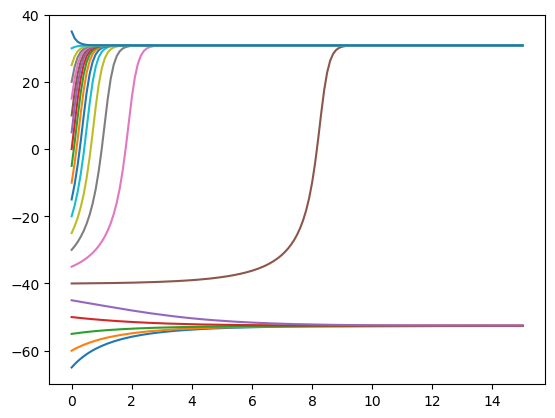

In [7]:
simtime = 15e-3

comp.inject = 0.0
for v in np.arange(-65e-3, 40e-3, 5e-3):
    comp.initVm = v
    moose.reinit()
    moose.start(simtime)
    t = np.linspace(0, simtime, len(vm_tab.vector))
    plt.plot(t*1e3, vm_tab.vector*1e3)

Visibly, the neuron goes to one of two voltages asymptotically, depending on the initial membrane potential. These are called its stable states. 

Using the analogy of a marble in a bowl, the stable state is like the bottom of the bowl, where the marble will end up if we wait long enough, and stay there forever. Also, if we slightly perturb the system at its stable state, it would come back to that same stable state.
<figure>
<img src="./media/images/dynamical_system_with_NaP/marble_into_basin_chatgpt.png" width="45%" alt="Marble in a basin">
    <img src="./media/images/dynamical_system_with_NaP/marble_into_basin_topview_arrows_chatgpt.png" width="45%" alt="Marble in a basin">
    <figcaption>Figure: A marble rolled down a basin stabilizes at the bottom, which is the stable state of the system. Left: side view, right: top view with arrows indicating the direction of movement from different starting positions (image generated with ChatGPT)</figcaption>
</figure>

Now if we had started the marble with 0 velocity at the stable state, it would not change state on its own. Such a state is called an equilibrium state.

In this specific case, the neuron has two stable equilibrium states, separated by an unstable equilibrium state. You can think of the unstable equilibrium as the top of an upside down bowl. If you carefully balance the marble at that point, it will stay there forever, but the slightest disturbance will make it roll down.

<figure>
<img src="./media/images/dynamical_system_with_NaP/marble_on_convex_topview_chatgpt.png" width="45%" alt="Marble on an upside down bowl">
    <img src="./media/images/dynamical_system_with_NaP/marble_on_convex_topview_arrows_chatgpt.png" width="45%" alt="Marble on an upside down bowl">
    <figcaption>Figure: A marble can be carefully placed on the top of an upside-down bowl, and it will stay there. But the slightest perturbation will make it roll away from that position, making it an unstable equilibrium state. Left: side view, right: top view with arrows indicating the direction of movement from different starting positions (image generated with ChatGPT)</figcaption>
</figure>

<figure>
<img src="./media/images/dynamical_system_with_NaP/marble_double_basin_analogy.svg" width="45%" alt="Marble analogy of the NaP model neuron">
    <figcaption>Figure: The neuron with NaP has two stable equilibrium states separated by an unstable equilibrium. The initial state determines where it will end up.</figcaption>
</figure>

## Changing the number of stable states

Now let us change the constant current injection to $I = 60 \mu A$ and rerun the simulation.

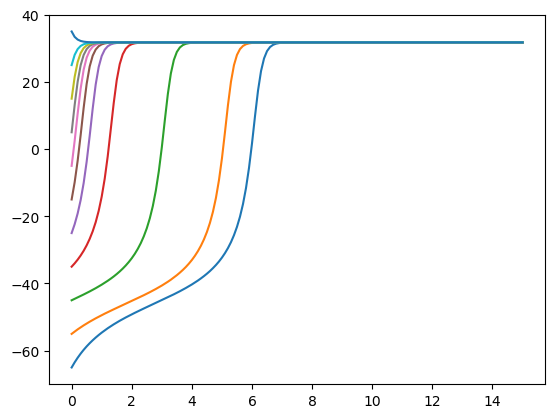

In [8]:
simtime = 15e-3

comp.inject = 60e-6   # 60 uA constant current injection
for v in np.arange(-65e-3, 40e-3, 10e-3):
    comp.initVm = v
    moose.reinit()
    moose.start(simtime)
    t = np.linspace(0, simtime, len(vm_tab.vector))
    plt.plot(t*1e3, vm_tab.vector*1e3)    

Now there is only one voltage towards which the membrane potential goes asymptotically. Thus injecting some constant current makes it converge to a single stable state